<a href="https://colab.research.google.com/github/ChanchalSaha48/nlp-learning-journey/blob/main/03_machine_learning/03_LinearSVC/02_linear_svm_sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opendatasets

In [2]:
import opendatasets as od

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from bs4 import BeautifulSoup

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [4]:
od.download('https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews')

Skipping, found downloaded files in "./imdb-dataset-of-50k-movie-reviews" (use force=True to force download)


In [5]:
df=pd.read_csv('/content/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [6]:
def preprocessing(text):
  text=BeautifulSoup(text,'html.parser').get_text()
  text=text.lower()
  return text

In [7]:
df['review']=df['review'].apply(preprocessing)

In [8]:
df['label']=df['sentiment'].map({
    'negative':0,
    'positive':1
})

In [9]:
df.head()

,review,sentiment,label
0,one of the other reviewers has mentioned that ...,positive,1
1,a wonderful little production. the filming tec...,positive,1
2,i thought this was a wonderful way to spend ti...,positive,1
3,basically there's a family where a little boy ...,negative,0
4,"petter mattei's ""love in the time of money"" is...",positive,1


## Split Dataset

In [10]:
x_train,x_test,y_train,y_test=train_test_split(df['review'],df['label'],test_size=0.2,random_state=42,stratify=df['label'])

In [11]:
print("Train shape: ",x_train.shape)
print("Test shape: ",x_test.shape)

Train shape:  (40000,)
Test shape:  (10000,)


## TF-IDF

In [12]:
tfidf=TfidfVectorizer(max_features=20000)

In [13]:
x_train_tfidf=tfidf.fit_transform(x_train)
x_test_tfidf=tfidf.transform(x_test)

## Train  Model

In [14]:
C_values=[0.01,0.1,1,10,100]


## C Parameter Experiment

In [15]:
results=[]
for C in C_values:
  # Create Linear SVM model
  model=LinearSVC(C=C)
  model.fit(x_train_tfidf,y_train)
  y_pred=model.predict(x_test_tfidf)
  acc=accuracy_score(y_test,y_pred)
  pre=precision_score(y_test,y_pred)
  rec=recall_score(y_test,y_pred)
  f1=f1_score(y_test,y_pred)

  # Strore results
  results.append({
      "c":C,
      "Accuracy: ":acc,
      "Precision: ":pre,
      "Recall: ":rec,
      "F1-score":f1
  })


In [16]:
results_df=pd.DataFrame(results)


In [17]:
results_df.head()

,c,Accuracy:,Precision:,Recall:,F1-score
0,0.01,0.8708,0.855581,0.8922,0.873507
1,0.10,0.9011,0.895640,0.9080,0.901778
2,1.00,0.8997,0.896449,0.9038,0.900110
3,10.00,0.8790,0.877189,0.8814,0.879290
4,100.00,0.8648,0.867002,0.8618,0.864393


## Best C selection

In [18]:
best_result= results_df.iloc[results_df['F1-score'].idxmax()]


In [19]:
print("Best result: ",best_result)


Best result:  c              0.100000
Accuracy:      0.901100
Precision:     0.895640
Recall:        0.908000
F1-score       0.901778
Name: 1, dtype: float64


## N-gram Experiment

In [20]:
n_gram=[1,2,3]
results=[]

for n in n_gram:
  tfidf=TfidfVectorizer(
      ngram_range=(1,n),
      max_features=20000
  )

  x_train_tfidf=tfidf.fit_transform(x_train)
  x_test_tfidf=tfidf.transform(x_test)

  model_n=LinearSVC(C=0.1)
  model_n.fit(x_train_tfidf,y_train)
  y_pred=model_n.predict(x_test_tfidf)

  acc=accuracy_score(y_test,y_pred)
  pre=precision_score(y_test,y_pred)
  rec=recall_score(y_test,y_pred)
  f1=f1_score(y_test,y_pred)
  results.append({
      'C':0.1,
      'N_gram':(1,n),
      'Accuracy':acc,
      'Precision':pre,
      'recall':rec,
      'F1-Score':f1
  })



In [21]:
res=pd.DataFrame(results)
res.head()

,C,N_gram,Accuracy,Precision,recall,F1-Score
0,0.1,"(1, 1)",0.9011,0.895640,0.908,0.901778
1,0.1,"(1, 2)",0.9077,0.901043,0.916,0.908460
2,0.1,"(1, 3)",0.9059,0.900217,0.913,0.906563


## Best N-gram selection

In [28]:
best_model= res.iloc[res['F1-Score'].idxmax()]

In [29]:
print(best_model)

C                 0.1
N_gram         (1, 2)
Accuracy       0.9077
Precision    0.901043
recall          0.916
F1-Score      0.90846
Name: 1, dtype: object


## Best Configuration
 ### c=0.1 + uni+Bi

In [30]:
tfidf_final=TfidfVectorizer(ngram_range=(1,2),max_features=20000)
x_train_final=tfidf_final.fit_transform(x_train)
x_test_final=tfidf_final.transform(x_test)

## Final model

In [31]:
best_con=LinearSVC(C=0.1)

In [34]:
best_con.fit(x_train_final,y_train)


LinearSVC(C=0.1)

In [37]:
y_pred_final=best_con.predict(x_test_final)

In [38]:
acc_final=accuracy_score(y_test,y_pred_final)
pre_final=precision_score(y_test,y_pred_final)
rec_final=recall_score(y_test,y_pred_final)
f1=f1_score(y_test,y_pred_final)
cm=confusion_matrix(y_test,y_pred_final)


In [39]:
print("Accuracy: ",acc_final)
print("Precision: ",pre_final)
print("Recall: ",rec_final)
print("F1-Score: ",f1)


Accuracy:  0.9077
Precision:  0.9010426913240213
Recall:  0.916
F1-Score:  0.9084597837945056


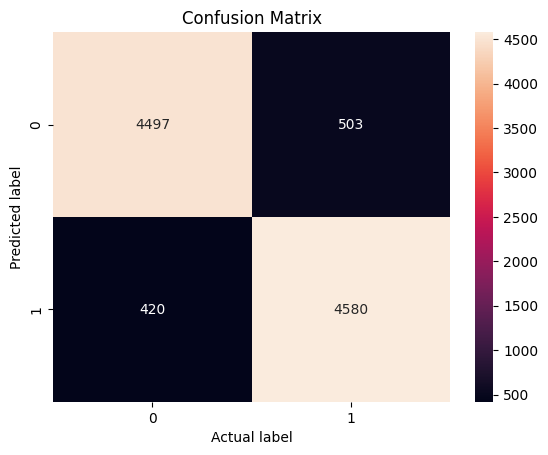

In [40]:
sns.heatmap(cm,annot=True,fmt='d')
plt.title("Confusion Matrix")
plt.xlabel('Actual label')
plt.ylabel("Predicted label")
plt.show()

In [41]:
print("Classification Reprot: ",classification_report(y_test,y_pred_final))

Classification Reprot:                precision    recall  f1-score   support

           0       0.91      0.90      0.91      5000
           1       0.90      0.92      0.91      5000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000

